In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

df = pd.read_csv('top2019.csv')
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(df.columns.tolist())

['id', 'name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature']


1.

Machine learning is the practice of training algorithms to find patterns in data so that they can make predictions or decisions on new, unseen examples, without being hardcoded on how to approach every case in the new examples. For this dataset, we can predict the effect of certain variables on another.

Our goal is to predict danceability based on specific audio variables in a song. It's a good target because it is scored 0-1 and logically should depend on other features, so we should use linear regression.


Shape: (50, 16)

Column types:
 id                   object
name                 object
artists              object
danceability        float64
energy              float64
key                 float64
loudness            float64
mode                float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms         float64
time_signature      float64
dtype: object

Summary statistics:
       danceability    energy        key   loudness       mode  speechiness  \
count     50.000000  50.00000  50.000000  50.000000  50.000000    50.000000   
mean       0.719400   0.60462   5.280000  -6.229000   0.580000     0.127582   
std        0.130358   0.16975   3.295266   2.725249   0.498569     0.103008   
min        0.351000   0.11100   0.000000 -14.505000   0.000000     0.029000   
25%        0.657500   0.52000   2.000000  -7.056000   0.000000     0.053675   
50%        

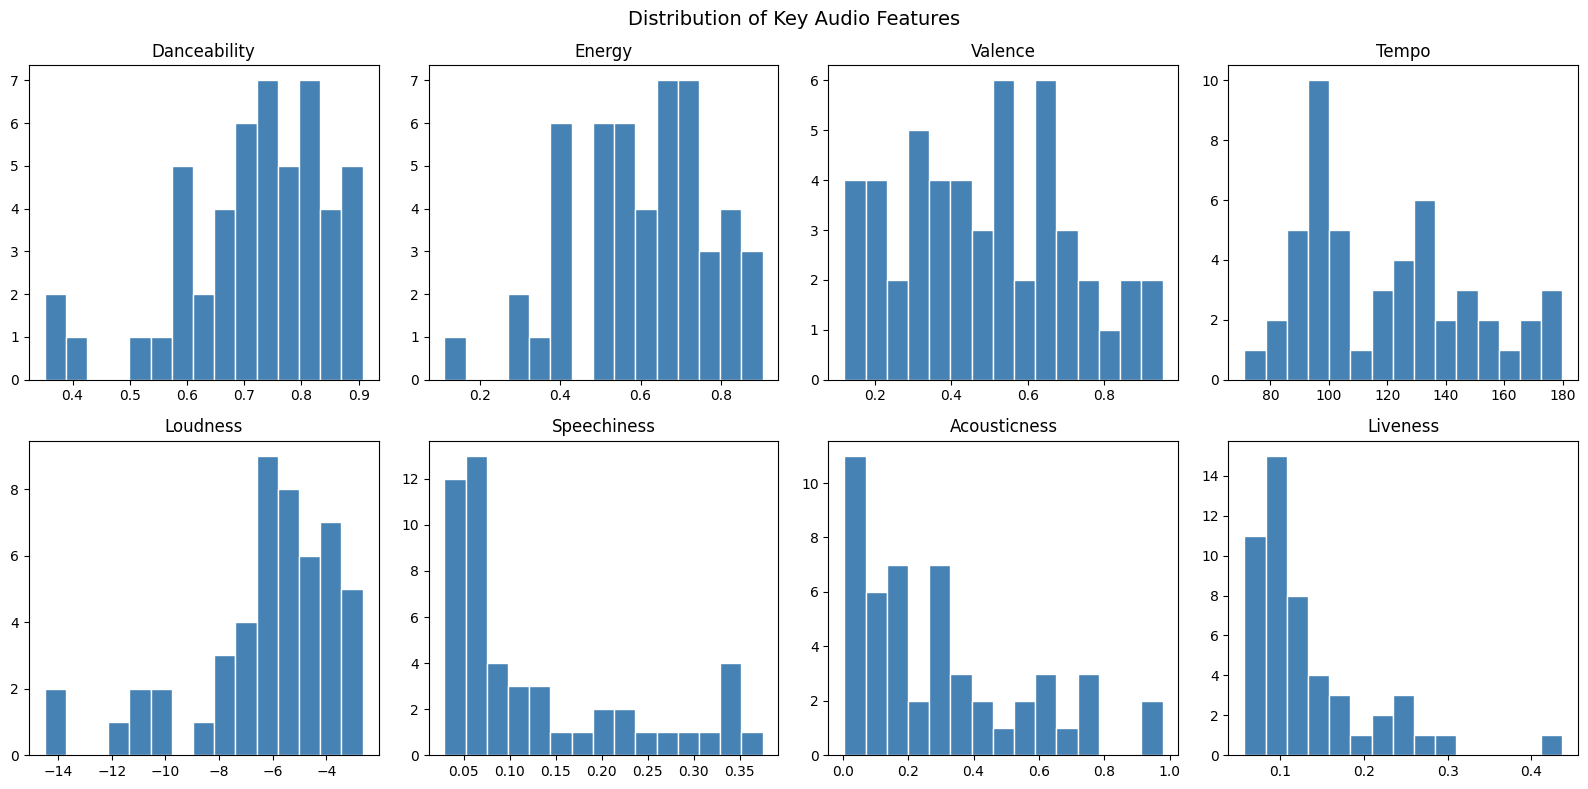

In [15]:
2.
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nSummary statistics:")
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
 
# Distribution plots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
plot_features = ['danceability','energy','valence','tempo',
                 'loudness','speechiness','acousticness','liveness']
for ax, feat in zip(axes.flatten(), plot_features):
    ax.hist(df[feat], bins=15, color='steelblue', edgecolor='white')
    ax.set_title(feat.capitalize())
plt.suptitle('Distribution of Key Audio Features', fontsize=14)
plt.tight_layout()
plt.show()

In [70]:
3.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features_3 = ['energy', 'valence', 'tempo']
X = df[features_3]
y = df['danceability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)     # Training samples: 40, Test samples: 10



In [82]:
4.
model1 = LinearRegression()
model1.fit(X_train, y_train)

for feature, coef in zip(features_3, model1.coef_):
    print(f'{feature}: {coef:.4f}')

print(f'Intercept: {model1.intercept_:.4f}')

# Coefficients from Model 1 (energy, valence, tempo):
# - Higher energy songs tend to be more danceable
# - Valence has the strongest positive effect on danceability
# - Tempo basically doesn't influence danceability
# - Theoretically if energy valence and tempo are all 0, danceability will be roughly 0.4



energy: 0.1685
valence: 0.2330
tempo: 0.0007
Intercept: 0.4117


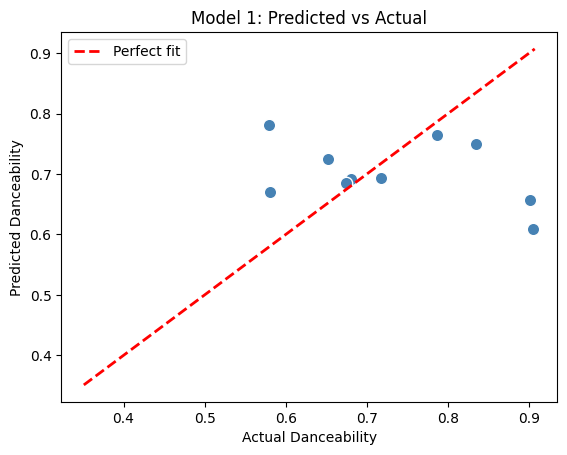

In [84]:
5.
y1_pred = model1.predict(X_test)

plt.scatter(y_test, y1_pred, color='steelblue', edgecolors='white', s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Danceability')
plt.ylabel('Predicted Danceability')
plt.title('Model 1: Predicted vs Actual')
plt.legend(); plt.show()


# If the model were very accurate, all of the data points would be far more clustered around the red line (with a low R^2)


In [126]:
6.
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X, y, test_size=0.8, random_state=42)
# Training samples: 10, Test samples: 40

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)
print(r2_score(y2_test, y2_pred))  
print(mean_squared_error(y2_test, y2_pred))

# The model has less data to learn from, so in general it will be less accurate. Here I randomly ended up with a better R^2, but thats chance


0.11658913065155685
0.012252011543698723


In [86]:
7.
all_features = [c for c in numeric_cols if c != 'danceability']
X3 = df[all_features]
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)
print(r2_score(y3_test, y3_pred))           
print(mean_squared_error(y3_test, y3_pred))

#Adding the features created so much noise and the model overfit to this noise, so our accuracy decreased


-2.1629623585594935
0.04143531297110674


danceability        1.000000
valence             0.391774
energy              0.273068
speechiness         0.227283
loudness            0.178688
key                 0.165208
instrumentalness    0.153419
tempo               0.149066
mode                0.007662
liveness           -0.088595
duration_ms        -0.132798
acousticness       -0.465118
time_signature           NaN
Name: danceability, dtype: float64


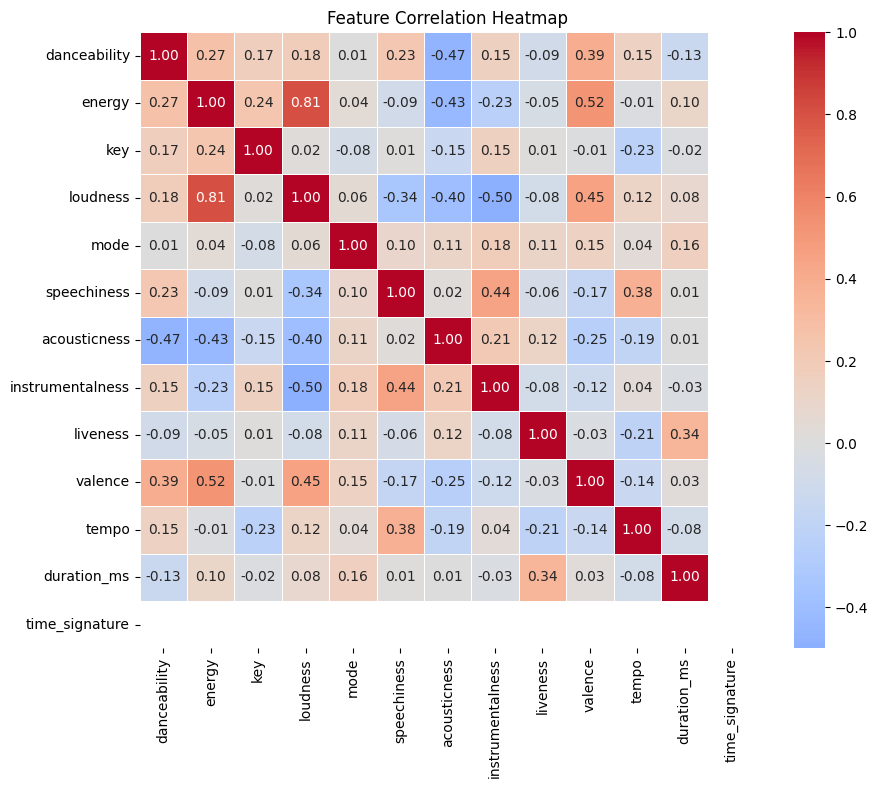

In [38]:
8.
corr = df[numeric_cols].corr()
print(corr['danceability'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

# The correlation matrix reveals which features are most linearly related to danceability, we should include the ones below
# Accousticness is strongest negative
# Valence is strongest positive
# Energy and speechiness is also high positive correlation


9. 
A good model will generalize well to new data as opposed to staking everything on a training set. Whats key is having enough quality training data relative to the number of variables, choosing vars that are actually related to the target var, and selecting the right model. To improve our model here, we could combine geatures, test other models, or use a bigger dataset.

In [148]:
10.
print(f"Model 1 R^2 Score: {r2_score(y_test, y1_pred)}")
mse1 = mean_squared_error(y_test, y1_pred)
print(f"Model 1 MSE: {mse1}")

print(f"Model 2 R^2 Score: {r2_score(y2_test, y2_pred)}")
mse2 = mean_squared_error(y2_test, y2_pred)
print(f"Model 2 MSE: {mse2}")

print(f"Model 3 R^2 Score: {r2_score(y3_test, y3_pred)}")
mse3 = mean_squared_error(y3_test, y3_pred)
print(f"Model 3 MSE: {mse3}")




Model 1 R^2 Score: -0.6048232497042276
Model 1 MSE: 0.02102344134284534
Model 2 R^2 Score: 0.11658913065155685
Model 2 MSE: 0.012252011543698723
Model 3 R^2 Score: -2.1629623585594935
Model 3 MSE: 0.04143531297110674


In [102]:
11. #W7/8 Extension

features = ['valence', 'acousticness', 'speechiness']
X = df[features]
y = df['danceability']

# scaling before Ridge/Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
# Training: 40 samples, Test: 10 samples



lasso = Lasso()
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_lasso = GridSearchCV(lasso, param_grid, cv=5,
                          scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

print(f"Best Lasso Alpha: {grid_lasso.best_params_}")
best_lasso = grid_lasso.best_estimator_
y_lasso_pred = best_lasso.predict(X_test)

# Best alpha of 0.001 means the model needs very little regularization and the features arent causing overfitting



model_ridge = Ridge()
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_ridge = GridSearchCV(model_ridge, param_grid, cv=5,
                           scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)

print(f"Best Ridge Alpha: {grid_ridge.best_params_}")
best_ridge = grid_ridge.best_estimator_
y_ridge_pred = best_ridge.predict(X_test)

# Best alpha of 1 means the model isn't multiplying the squares of the error by anything


Best Alpha: {'alpha': 0.001}
Best Alpha: {'alpha': 1}
